In [1]:
import ast
import yaml
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
root = Path("../metadata")

images = pd.read_csv(
    root / "openneuro_images.csv", dtype={"ce": str, "rez": str, "part": str, "task": str}
)
parts = pd.read_csv(root / "openneuro_participants.csv")

# drop extra columns
images = images.drop(columns=["acq", "rec", "ce", "rez", "echo", "part", "task"])

# drop exclude datasets
exclude_list = yaml.safe_load((root / "openneuro_exclude_datasets.yaml").read_text())
images = images.loc[~images["dataset"].isin(exclude_list)]
parts = parts.loc[~parts["dataset"].isin(exclude_list)]

# drop extra images
images = images.loc[images["suffix"].isin(["T1w", "T2w", "FLAIR"])]

# add image columns
images["shape"] = images["shape"].map(ast.literal_eval)
images["pixdim"] = images["pixdim"].map(ast.literal_eval)
images["ndim"] = images["shape"].map(len)
images["res"] = images["pixdim"].map(max)
images["fov"] = [
    [a * b for a, b in zip(shape[:3], pixdim)]
    for shape, pixdim in zip(images["shape"], images["pixdim"])
]
images["vol"] = [np.prod(fov) for fov in images["fov"]]

# drop longitudinal entries for now
parts = parts.drop(columns=["ses"]).drop_duplicates(["dataset", "sub"])

print(f"images:       {len(images):,}")
print(f"participants: {len(parts):,}")
print(images["suffix"].value_counts().to_markdown())

images:       77,317
participants: 73,458
| suffix   |   count |
|:---------|--------:|
| T1w      |   57698 |
| T2w      |   13916 |
| FLAIR    |    5703 |


## Image inventory

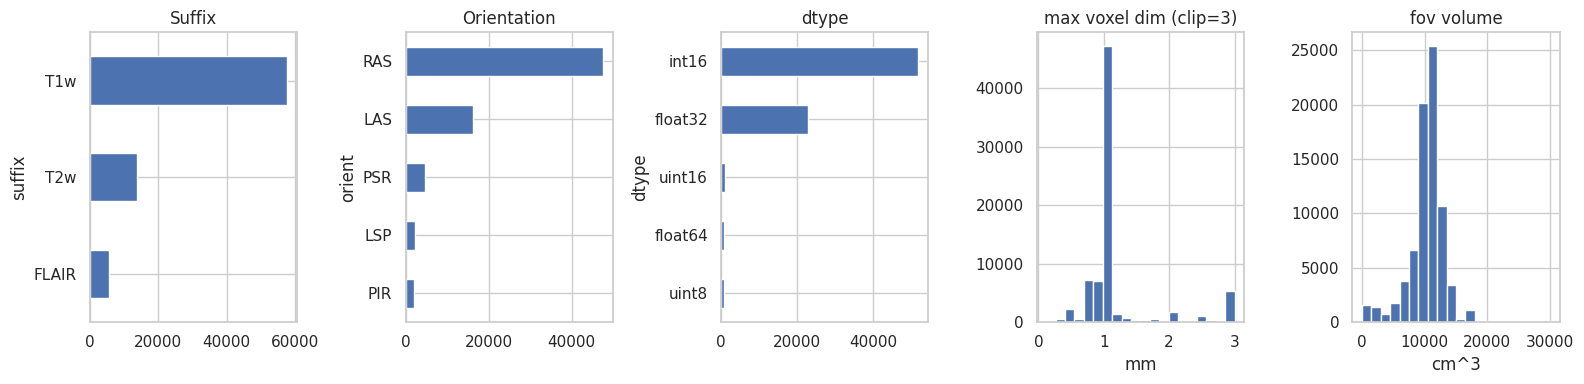

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

# Suffix
images["suffix"].value_counts().head(3).plot.barh(ax=axes[0])
axes[0].set_title("Suffix")
axes[0].invert_yaxis()

# Orientation
images["orient"].value_counts().head(5).plot.barh(ax=axes[1])
axes[1].set_title("Orientation")
axes[1].invert_yaxis()

# dtype
images["dtype"].value_counts().head(5).plot.barh(ax=axes[2])
axes[2].set_title("dtype")
axes[2].invert_yaxis()

# voxel dim
images["res"].clip(upper=3).hist(bins=20, ax=axes[3])
axes[3].set_title("max voxel dim (clip=3)")
axes[3].set_xlabel("mm")

# fov volume
(images["vol"] / 1e3).clip(upper=3e4).hist(bins=20, ax=axes[4])
axes[4].set_title("fov volume")
axes[4].set_xlabel("cm^3")

plt.tight_layout()
plt.show()

In [5]:
print(images["suffix"].value_counts())
print(images["orient"].value_counts().head(10))

suffix
T1w      57698
T2w      13916
FLAIR     5703
Name: count, dtype: int64
orient
RAS    47486
LAS    16237
PSR     4785
LSP     2264
PIR     1999
PIL     1171
LPS     1152
LIP      702
IPL      570
LIA      496
Name: count, dtype: int64


In [6]:
# Most common T1w shapes
for suffix in ["T1w", "T2w", "FLAIR"]:
    print(f"top shapes {suffix}:")
    counts = images.loc[images["suffix"] == suffix, "shape"].map(str).value_counts()
    print(counts.head(10).to_string())

top shapes T1w:
shape
[176, 256, 256]    8313
[192, 256, 256]    5885
[160, 256, 256]    3391
[256, 256, 176]    2851
[208, 256, 256]    2330
[256, 256, 160]    1980
[256, 256, 256]    1880
[176, 224, 256]    1165
[240, 240, 220]     891
[224, 320, 320]     872
top shapes T2w:
shape
[176, 256, 256]    2250
[512, 512, 64]      884
[208, 300, 320]     570
[128, 128, 30]      564
[204, 256, 256]     432
[256, 256, 72]      423
[256, 256, 60]      377
[240, 256, 256]     353
[360, 512, 512]     335
[512, 512, 65]      318
top shapes FLAIR:
shape
[160, 256, 256]    851
[200, 512, 512]    550
[256, 256, 32]     503
[256, 256, 42]     406
[256, 256, 30]     236
[176, 512, 512]    228
[256, 220, 256]    190
[384, 512, 28]     188
[204, 256, 256]    184
[336, 221, 336]    169


## Data quality

In [7]:
# Non-3D images
non3d = images[images["ndim"] != 3]
print(f"non-3D images: {len(non3d)} ({100 * len(non3d) / len(images):.1f}%)")
if len(non3d):
    print(non3d[["path", "shape"]].to_string())

non-3D images: 67 (0.1%)
                                                                                          path               shape
2483                                                    ds000210/sub-02/anat/sub-02_T1w.nii.gz  [256, 256, 176, 1]
2485                                                    ds000210/sub-04/anat/sub-04_T1w.nii.gz  [256, 256, 176, 1]
2486                                                    ds000210/sub-05/anat/sub-05_T1w.nii.gz  [256, 256, 176, 1]
2488                                                    ds000210/sub-07/anat/sub-07_T1w.nii.gz  [256, 256, 176, 1]
2493                                                    ds000210/sub-12/anat/sub-12_T1w.nii.gz  [256, 256, 176, 1]
2498                                                    ds000210/sub-17/anat/sub-17_T1w.nii.gz  [256, 256, 176, 1]
2500                                                    ds000210/sub-19/anat/sub-19_T1w.nii.gz  [256, 256, 176, 1]
2501                                                   

In [8]:
# File size outliers
size_mb = images["size"] / 1e6
print("\nFile size (MB):")
print(
    f"  p01: {size_mb.quantile(0.01):.2f}  p05: {size_mb.quantile(0.05):.2f}  "
    f"median: {size_mb.median():.2f}  p95: {size_mb.quantile(0.95):.2f}  max: {size_mb.max():.2f}"
)

small_mask = images["size"] < 100_000
print(f"\nVery small files (<100 KB): {small_mask.sum()}")
print(
    images.loc[small_mask, ["dataset", "sub", "suffix", "size", "shape"]]
    .sort_values("size")
    .head(10)
)

big_mask = images["size"] > 100_000_000
print(f"\nVery big files (>100 MB): {big_mask.sum()}")
print(
    images.loc[big_mask, ["dataset", "sub", "suffix", "size", "shape"]]
    .sort_values("size", ascending=False)
    .head(10)
)


File size (MB):
  p01: 0.83  p05: 2.29  median: 9.52  p95: 41.60  max: 567.56

Very small files (<100 KB): 16
        dataset    sub suffix   size            shape
47915  ds004884  M2022  FLAIR   3926   [232, 256, 19]
11239  ds002320     47    T1w   6553   [16, 320, 320]
11235  ds002320     43    T1w   6934   [17, 320, 320]
11253  ds002320     55    T1w   8579   [21, 320, 320]
56845  ds005226     54    T1w  16375  [192, 256, 256]
40124  ds004552     01    T1w  20864  [144, 192, 192]
48496  ds004884  M2191    T2w  22900  [176, 256, 256]
48509  ds004884  M2192    T2w  23250  [176, 256, 256]
7317   ds001722     06    T1w  23867    [162, 162, 2]
56841  ds005226     50    T1w  32750  [192, 256, 256]

Very big files (>100 MB): 198
        dataset        sub suffix       size            shape
24452  ds003563       yv98    T1w  567560784  [640, 880, 880]
24453  ds003563       yv98    T1w  566766364  [640, 880, 880]
24450  ds003563       yv98    T1w  562046157  [640, 880, 880]
24455  ds003563 

## Filtering

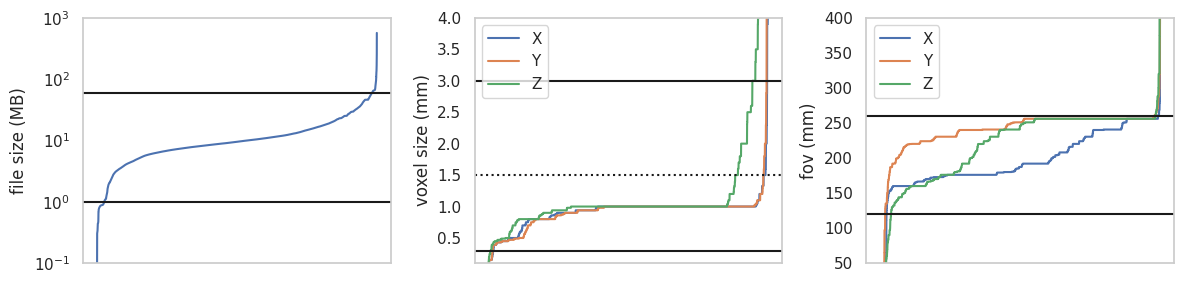

In [9]:
size_mb = images["size"] / 1e6
res_min = images["pixdim"].map(min)
res_max = images["pixdim"].map(max)
res_x = images["pixdim"].map(lambda x: x[0])
res_y = images["pixdim"].map(lambda x: x[1])
res_z = images["pixdim"].map(lambda x: x[2])
fov_min = images["fov"].map(min)
fov_max = images["fov"].map(max)
fov_x = images["fov"].map(lambda x: x[0])
fov_y = images["fov"].map(lambda x: x[1])
fov_z = images["fov"].map(lambda x: x[2])
n_im = len(images)

res_low = 0.3
res_z_high = 3.0
res_xy_high = 1.5
size_low = 1.0
size_high = 60.0
fov_low = 120
fov_high = 260

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].plot(np.sort(size_mb))
axes[0].axhline(size_low, color="k")
axes[0].axhline(size_high, color="k")
axes[0].set_yscale("log")
axes[0].set_ylim(0.1, 1000)
axes[0].set_ylabel("file size (MB)")
axes[0].set_xticks([])
axes[0].grid(False)

axes[1].plot(np.sort(res_x), label="X")
axes[1].plot(np.sort(res_y), label="Y")
axes[1].plot(np.sort(res_z), label="Z")
axes[1].axhline(res_low, color="k")
axes[1].axhline(res_z_high, color="k")
axes[1].axhline(res_xy_high, color="k", ls=":")
axes[1].set_ylim(0.1, 4.0)
axes[1].set_xticks([])
axes[1].set_ylabel("voxel size (mm)")
axes[1].legend()
axes[1].grid(False)

axes[2].plot(np.sort(fov_x), label="X")
axes[2].plot(np.sort(fov_y), label="Y")
axes[2].plot(np.sort(fov_z), label="Z")
axes[2].axhline(fov_low, color="k")
axes[2].axhline(fov_high, color="k")
axes[2].set_ylim(50, 400)
axes[2].set_ylabel("fov (mm)")
axes[2].set_xticks([])
axes[2].legend()
axes[2].grid(False)

plt.tight_layout()
plt.show()

In [10]:
include_mask = (
    (images["ndim"] == 3)
    & (size_mb >= size_low)
    & (size_mb <= size_high)
    & (res_min >= res_low)
    & (res_x <= res_xy_high)
    & (res_y <= res_xy_high)
    & (res_z <= res_z_high)
    & (fov_min >= fov_low)
    & (fov_max <= fov_high)
)

print(
    f"Total include include images {include_mask.sum()}/{len(include_mask)} {100 * include_mask.mean():.2f}%"
)

Total include include images 65994/77317 85.36%


## Duplicates

In [11]:
duplicates = images.groupby("md5").size()
duplicates = duplicates[duplicates > 1]
duplicates = duplicates.sort_values(ascending=False)
print(f"Duplicate images: {len(duplicates)}/{duplicates.sum()}")

Duplicate images: 1961/4152


In [12]:
# Final apply filter
images_include = images.loc[include_mask].copy()
images_include = images_include.drop_duplicates(["md5"])
print(f"Total include images: {len(images_include)}/{len(images)}")

Total include images: 64287/77317


In [13]:
# Join coverage
joined = images_include.merge(parts, on=["dataset", "sub"], how="left", validate="m:1")
has_sex = joined["sex"].notna()
has_age = joined["age"].notna()
has_both = has_sex & has_age
labeled = joined[has_age].copy()
print(f"\njoin coverage (of {len(images_include):,} images):")
print(f"  matched participant row: {joined['sex'].notna().sum() + joined['sex'].isna().sum():,}")
print(f"  non-null sex:            {has_sex.sum():,} ({100 * has_sex.mean():.1f}%)")
print(f"  non-null age:            {has_age.sum():,} ({100 * has_age.mean():.1f}%)")
print(f"  both sex + age:          {has_both.sum():,} ({100 * has_both.mean():.1f}%)")


join coverage (of 64,287 images):
  matched participant row: 64,287
  non-null sex:            44,377 (69.0%)
  non-null age:            42,649 (66.3%)
  both sex + age:          37,929 (59.0%)


## Demographics

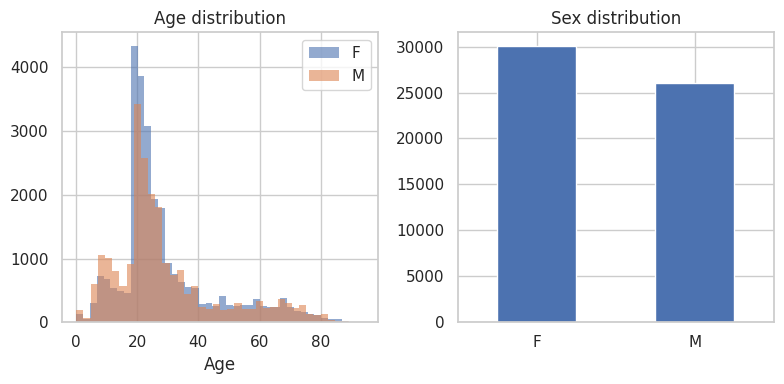

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Age histogram by sex
for sex, grp in parts.groupby("sex"):
    grp["age"].hist(bins=40, alpha=0.6, label=sex, ax=axes[0], ec="none")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")
axes[0].legend()

# Sex balance
parts["sex"].value_counts().plot.bar(ax=axes[1])
axes[1].set_title("Sex distribution")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

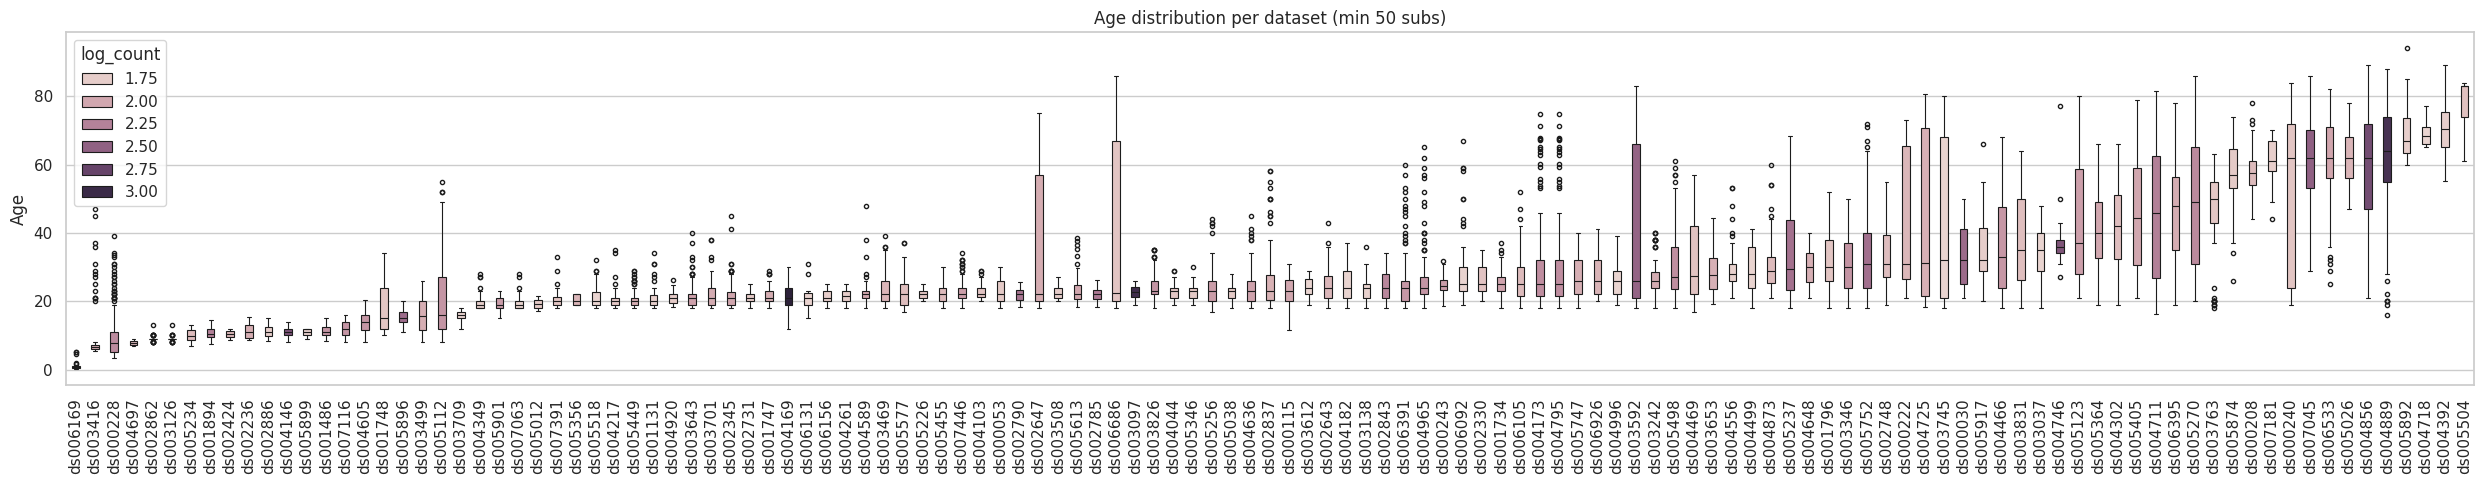

In [15]:
# Age distribution per dataset
ds_counts = labeled.groupby("dataset")["sub"].nunique()
eligible = ds_counts[ds_counts >= 50].index
plot_data = labeled[labeled["dataset"].isin(eligible)].copy()
plot_data = plot_data.drop_duplicates(["dataset", "sub"])
order = plot_data.groupby("dataset")["age"].median().sort_values().index
plot_data["log_count"] = np.log10(ds_counts.loc[plot_data["dataset"]].values)

fig, ax = plt.subplots(figsize=(len(eligible) * 0.2, 5))
sns.boxplot(
    data=plot_data,
    x="dataset",
    y="age",
    order=order,
    ax=ax,
    linewidth=0.8,
    hue="log_count",
    width=0.4,
    fliersize=3,
)
ax.set_title("Age distribution per dataset (min 50 subs)")
ax.set_ylabel("Age")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

- `ds004889`: SOOP
- `ds004169`: QTIM
- `ds003097`: AOMIC-ID1000
- `ds007045`: Real-world Multi-Institutional Glioblastoma
- `ds004856`: DLBS
- `ds003592`: Neurocognitive aging data release (some repeat subs with `ds000210`)


## Dataset-level overview

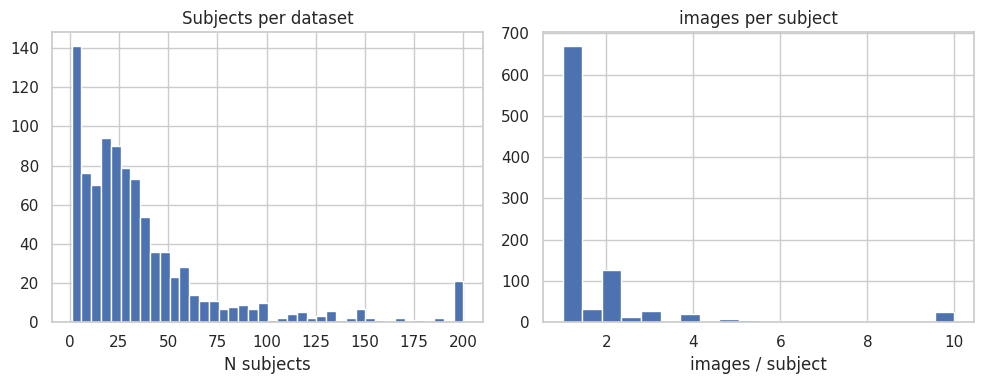

In [16]:
ds = (
    joined.groupby("dataset")
    .agg(
        n_images=("path", "count"),
        n_subs=("sub", "nunique"),
        frac_labeled=("age", lambda x: x.notna().mean()),
    )
    .reset_index()
)
ds["im_per_sub"] = ds["n_images"] / ds["n_subs"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# subjects per dataset
ds["n_subs"].clip(upper=200).hist(bins=40, ax=axes[0])
axes[0].set_title("Subjects per dataset")
axes[0].set_xlabel("N subjects")

# images per subject
ds["im_per_sub"].clip(upper=10).hist(bins=20, ax=axes[1])
axes[1].set_title("images per subject")
axes[1].set_xlabel("images / subject")

plt.tight_layout()
plt.show()

In [17]:
print("datasets with large num subs:")
print(
    ds.query("n_subs >= 200").sort_values("n_subs", ascending=False).head(20).to_string(index=False)
)

print("datasets with large num images per sub:")
print(
    ds.query("im_per_sub >= 10")
    .sort_values("im_per_sub", ascending=False)
    .head(20)
    .to_string(index=False)
)

datasets with large num subs:
 dataset  n_images  n_subs  frac_labeled  im_per_sub
ds004889      2224    1330      0.629946    1.672180
ds004169      1341    1201      1.000000    1.116570
ds003097      2768     928      1.000000    2.982759
ds005602       683     522      0.000000    1.308429
ds004856      1851     464      1.000000    3.989224
ds004146      1328     411      1.000000    3.231144
ds004746       398     395      1.000000    1.007595
ds002345       425     345      0.240000    1.231884
ds003604       826     322      0.000000    2.565217
ds007045       790     321      1.000000    2.461059
ds000221       661     318      0.000000    2.078616
ds003592       552     301      0.996377    1.833887
ds000030       265     265      1.000000    1.000000
ds005896       519     262      1.000000    1.980916
ds005752      1081     249      0.993525    4.341365
ds005237       480     240      1.000000    2.000000
ds004884      1089     230      0.000000    4.734783
ds002790       2

## Save file list

In [18]:
include_paths = images_include["path"].values
np.savetxt(root / "openneuro_include_filelist.txt", include_paths, fmt="%s")

In [19]:
counts = {}
counts["datasets"] = images_include["dataset"].nunique()
counts["subjects"] = len(images_include.groupby(["dataset", "sub"]))
counts["images"] = len(images_include)
counts.update(images_include["suffix"].value_counts().to_dict())
print(pd.DataFrame([counts]).to_markdown(index=False))

|   datasets |   subjects |   images |   T1w |   T2w |   FLAIR |
|-----------:|-----------:|---------:|------:|------:|--------:|
|        939 |      39143 |    64287 | 51591 |  9159 |    3537 |
